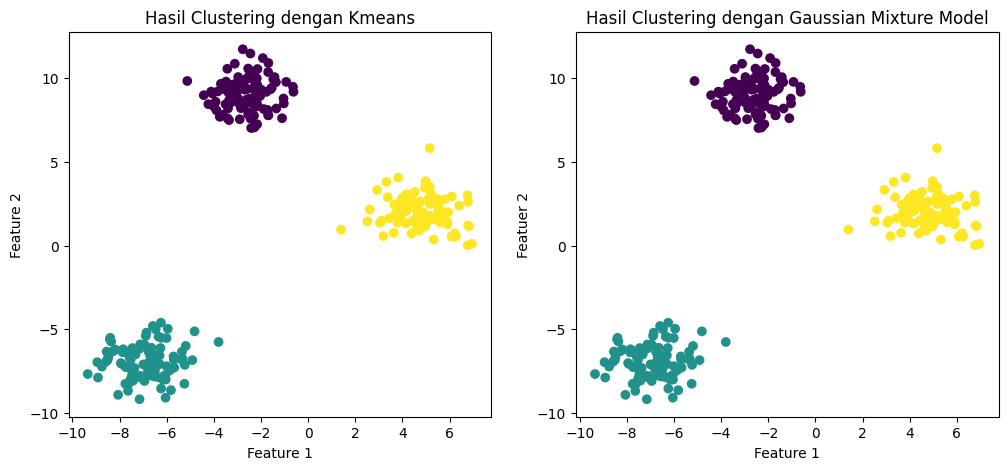

,Feature 1,Feature 2,KMeans Cluster,GMM Cluster
0,-7.338988,-7.729954,1,1
1,-7.740041,-7.264665,1,1
2,-1.686653,7.793442,0,0
3,4.422198,3.071947,2,2
4,-8.917752,-7.888196,1,1


In [11]:
# =================
# Soal No. 1
# =================

# Import library
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# 1. Generate data
X, y_true = make_blobs (
    n_samples=300,
    centers=3,
    random_state=42
)

# ubah ke DataFrame biar rapi
df = pd.DataFrame(X, columns=["Feature 1", "Feature 2"])

# 2. Clustering dengan KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df["KMeans Cluster"] = kmeans.fit_predict(X)

# 3. Clustering dengan Gaussian Mixture Model
gmm = GaussianMixture(n_components=3, random_state=42)
df["GMM Cluster"] = gmm.fit_predict(X)

# 4. Visualisasi hasil clustering
plt.figure(figsize=(12, 5))

# Plot Kmeans
plt.subplot(1, 2, 1)
plt.scatter(df["Feature 1"], df["Feature 2"], c=df["KMeans Cluster"])
plt.title("Hasil Clustering dengan Kmeans")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Plot GMM
plt.subplot(1, 2 ,2)
plt.scatter(df["Feature 1"], df["Feature 2"], c=df["GMM Cluster"])
plt.title("Hasil Clustering dengan Gaussian Mixture Model")
plt.xlabel("Feature 1")
plt.ylabel("Featuer 2")

plt.show()

# Tampilkan beberapa data
df.head()

Solusi terbaik: [ 0.04736983  0.02637093 -0.25048462  0.02772296 -0.03440098]
Nilai minimum ditemukan: 0.06763385986007464
Generasi saat nilai minimum terbaik ditemukan: 34


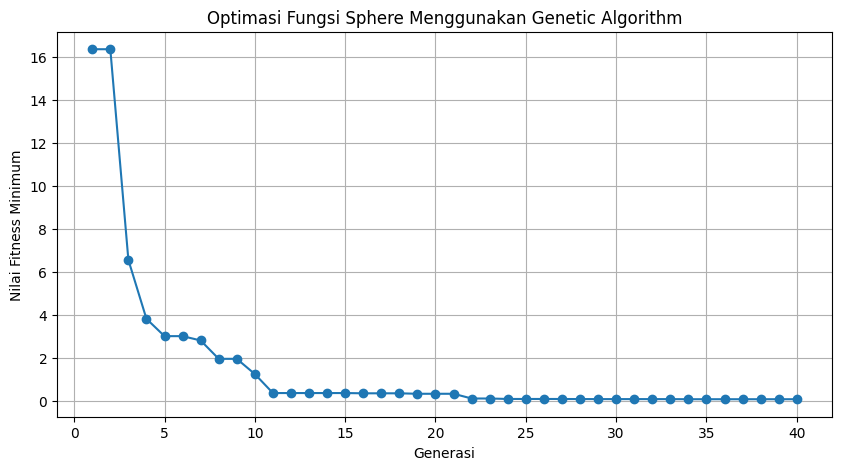

In [12]:
# =================
# Soal No. 2
# =================

# import numpy as np
import matplotlib.pyplot as plt

# 1. Fungsi Sphere
def sphere_function(x):
    return np.sum(x ** 2)


# 2. Parameter GA
DIMENSION = 5
LOWER_BOUND = -5.0
UPPER_BOUND = 5.0
POP_SIZE = 50
GENERATIONS = 40
MUTATION_RATE = 0.1

np.random.seed(42)


# 3. Inisialisasi Populasi
population = np.random.uniform(
    LOWER_BOUND,
    UPPER_BOUND,
    size=(POP_SIZE, DIMENSION)
)

best_values = []
best_solution = None
best_fitness = float("inf")
generation_found = 0


# 4. Genetic Algorithm
for gen in range(1, GENERATIONS + 1):

    # Hitung nilai fitness setiap individu
    fitness = np.array([sphere_function(ind) for ind in population])

    # Ambil individu terbaik
    min_index = np.argmin(fitness)

    if fitness[min_index] < best_fitness:
        best_fitness = fitness[min_index]
        best_solution = population[min_index].copy()
        generation_found = gen

    best_values.append(best_fitness)

    # Seleksi: ambil 50% individu terbaik
    sorted_indices = np.argsort(fitness)
    selected = population[sorted_indices[:POP_SIZE // 2]]

    # Crossover: membuat anak dari dua parent secara acak
    children = []

    while len(children) < POP_SIZE // 2:
        parent1 = selected[np.random.randint(len(selected))]
        parent2 = selected[np.random.randint(len(selected))]

        # Random crossover
        crossover_point = np.random.randint(1, DIMENSION)
        child = np.concatenate(
            [parent1[:crossover_point], parent2[crossover_point:]]
        )

        # Mutation sederhana
        if np.random.rand() < MUTATION_RATE:
            mutation_index = np.random.randint(DIMENSION)
            child[mutation_index] += np.random.normal(0, 1)

            # Pastikan tetap dalam range [-5, 5]
            child[mutation_index] = np.clip(
                child[mutation_index],
                LOWER_BOUND,
                UPPER_BOUND
            )

        children.append(child)

    children = np.array(children)

    # Populasi baru = parent terpilih + children
    population = np.vstack((selected, children))


# 5. Tampilkan Hasil
print("Solusi terbaik:", best_solution)
print("Nilai minimum ditemukan:", best_fitness)
print("Generasi saat nilai minimum terbaik ditemukan:", generation_found)


# 6. Visualisasi
plt.figure(figsize=(10, 5))
plt.plot(range(1, GENERATIONS + 1), best_values, marker="o")
plt.title("Optimasi Fungsi Sphere Menggunakan Genetic Algorithm")
plt.xlabel("Generasi")
plt.ylabel("Nilai Fitness Minimum")
plt.grid(True)
plt.show()

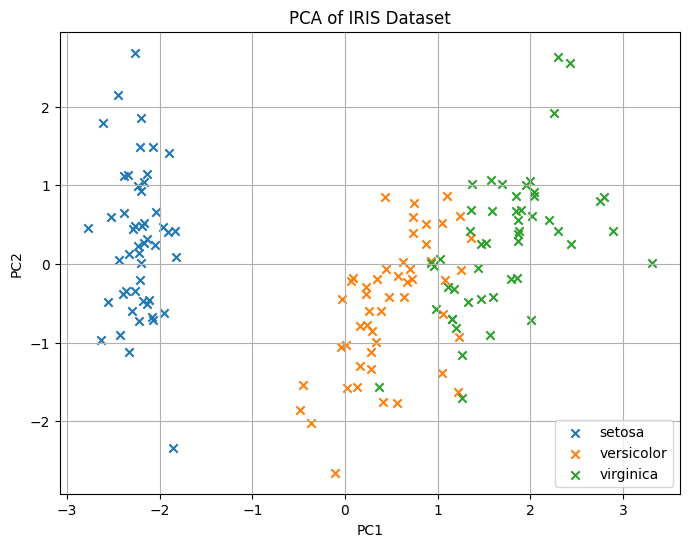

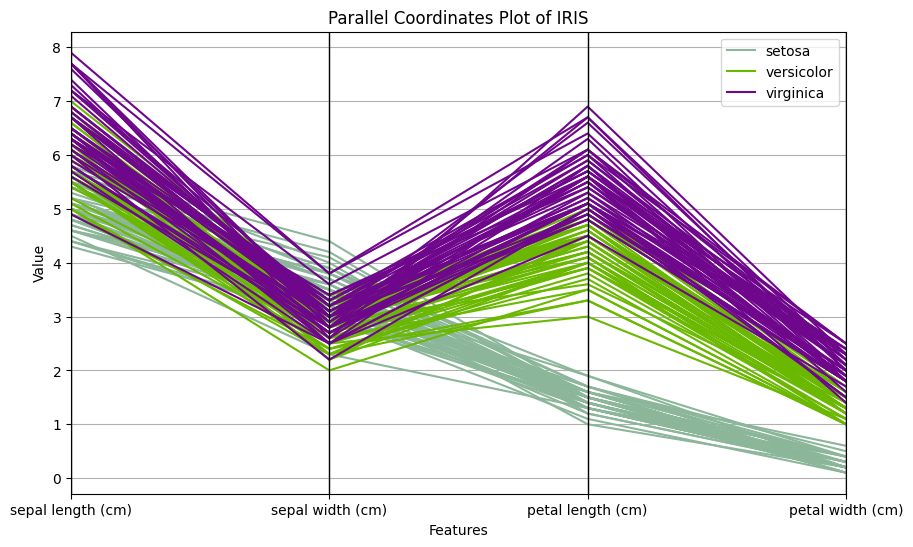

In [13]:
# =================
# Soal. No. 3
# =================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pandas.plotting import parallel_coordinates


# 1. Load Dataset IRIS
iris = load_iris()

X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Membuat DataFrame
df = pd.DataFrame(X, columns=feature_names)
df["species"] = [target_names[i] for i in y]


# 2. Standardisasi Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 3. PCA menjadi 2 Dimensi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["species"] = df["species"]


# 4. Scatter Plot Hasil PCA
plt.figure(figsize=(8, 6))

for species in target_names:
    data = df_pca[df_pca["species"] == species]
    plt.scatter(
        data["PC1"],
        data["PC2"],
        label=species,
        marker="x"
    )

plt.title("PCA of IRIS Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()


# 5. Parallel Coordinates Plot
plt.figure(figsize=(10, 6))

parallel_coordinates(
    df,
    class_column="species"
)

plt.title("Parallel Coordinates Plot of IRIS")
plt.xlabel("Features")
plt.ylabel("Value")
plt.grid(True)
plt.show()